# *Bird Species Observation Analysis Project*


**Project Type:** Data Cleaning,Exploratory Data Analysis(EDA)

**Contribution:** Individual:-Anjali Mishra

## **Project Summary**

The Bird Species Observation Analysis Project focuses on analyzing avian biodiversity across forest and grassland ecosystems. The raw data, collected through field surveys, contained inconsistencies, missing values, and lacked structure, making direct analysis challenging.
The primary objective of this project is to clean, preprocess, and analyze this observational data using Python, and visualize key biodiversity trends through Power BI dashboards. The dataset includes various attributes like species scientific names, common names, habitat types, environmental factors (sky, wind, disturbances), and observation metrics such as temperature, distance, and PIF Watchlist status.
By leveraging Python for data cleaning and exploratory data analysis (EDA), we structured the data to extract meaningful patterns like habitat preferences, seasonal observation trends, and environmental influences on bird sightings. The final cleaned dataset enables robust visual analysis, aiding in ecological research, biodiversity assessment, and conservation planning efforts.

## **Problem Statement**

Bird species diversity and their behavioral patterns are affected by changing environmental conditions and human disturbances. However, the raw observation data collected from field surveys is inconsistent and lacks structured insights for biodiversity analysis.

## **Business Objective**

- Clean and preprocess raw bird observation data from multiple sources.
- Analyze species distribution across different habitats (Forest vs Grassland).
- Identify seasonal observation trends and environmental factors affecting sightings.
- Build a Power BI Dashboard to visualize biodiversity patterns for ecological research and conservation planning.


# 1.*Know Your Data*

In [5]:
pip install pandas


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: numpy in c:\users\acer\appdata\local\programs\python\python313\lib\site-packages (2.2.4)




[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
!pip install openpyxl



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd       
import numpy as np         
import matplotlib.pyplot as plt  
import seaborn as sns      
import warnings           


# 2.*Dataset Loading*

In [18]:
import pandas as pd

forest_file = 'Bird_Monitoring_Data_FOREST.xlsx'
grassland_file = 'Bird_Monitoring_Data_GRASSLAND.xlsx'

def read_all_sheets(file):
    xl = pd.ExcelFile(file)
    sheets = xl.sheet_names
    df_list = []
    for sheet in sheets:
        df = xl.parse(sheet)
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

forest_data = read_all_sheets(forest_file)
grassland_data = read_all_sheets(grassland_file)

combined_data = pd.concat([forest_data, grassland_data], ignore_index=True)

print("Combined Data Shape:", combined_data.shape)

combined_data.to_csv('Bird_Observation_Master_Data.csv', index=False)

print("Master Data CSV Created Successfully!")


C:\Users\acer\AppData\Local\Temp\ipykernel_10216\2142413515.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(df_list, ignore_index=True)


Combined Data Shape: (17077, 31)
Master Data CSV Created Successfully!


# 3.*DATASET FIRST VIEW*

In [3]:
import pandas as pd

# Read the Master CSV file
df = pd.read_csv('Bird_Observation_Master_Data.csv')

# Data Shape
print("Data Shape:", df.shape)

# Top 5 rows 
df.head()

Data Shape: (17077, 31)


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,TaxonCode,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,NaN,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,NaN,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN,NaN


# 4.*DATASET COLUMN COUNT*

In [28]:
df.columns

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'TaxonCode', 'Previously_Obs'],
      dtype='object')

# 5.*DATASET INFORMATION*

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Admin_Unit_Code              17077 non-null  object 
 1   Sub_Unit_Code                722 non-null    object 
 2   Site_Name                    8546 non-null   object 
 3   Plot_Name                    17077 non-null  object 
 4   Location_Type                17077 non-null  object 
 5   Year                         17077 non-null  int64  
 6   Date                         17077 non-null  object 
 7   Start_Time                   17077 non-null  object 
 8   End_Time                     17077 non-null  object 
 9   Observer                     17077 non-null  object 
 10  Visit                        17077 non-null  int64  
 11  Interval_Length              17077 non-null  object 
 12  ID_Method                    17075 non-null  object 
 13  Distance        

# 6.*UNDERSTANDING YOUR VARIABLE*

We will explore the dataset to understand what variables (columns) are available, their data types, and how they contribute to the analysis.

In [4]:
#Display all column names and data types
print(df.dtypes)

Admin_Unit_Code                 object
Sub_Unit_Code                   object
Site_Name                       object
Plot_Name                       object
Location_Type                   object
Year                             int64
Date                            object
Start_Time                      object
End_Time                        object
Observer                        object
Visit                            int64
Interval_Length                 object
ID_Method                       object
Distance                        object
Flyover_Observed                  bool
Sex                             object
Common_Name                     object
Scientific_Name                 object
AcceptedTSN                    float64
NPSTaxonCode                   float64
AOU_Code                        object
PIF_Watchlist_Status              bool
Regional_Stewardship_Status       bool
Temperature                    float64
Humidity                       float64
Sky                      

# 7.*Check Unique Values For Each Variable*

In [5]:
# Check unique values count for each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Admin_Unit_Code: 11 unique values
Sub_Unit_Code: 8 unique values
Site_Name: 70 unique values
Plot_Name: 609 unique values
Location_Type: 2 unique values
Year: 1 unique values
Date: 64 unique values
Start_Time: 318 unique values
End_Time: 318 unique values
Observer: 3 unique values
Visit: 3 unique values
Interval_Length: 4 unique values
ID_Method: 3 unique values
Distance: 2 unique values
Flyover_Observed: 2 unique values
Sex: 3 unique values
Common_Name: 126 unique values
Scientific_Name: 127 unique values
AcceptedTSN: 125 unique values
NPSTaxonCode: 108 unique values
AOU_Code: 126 unique values
PIF_Watchlist_Status: 2 unique values
Regional_Stewardship_Status: 2 unique values
Temperature: 210 unique values
Humidity: 432 unique values
Sky: 5 unique values
Wind: 4 unique values
Disturbance: 4 unique values
Initial_Three_Min_Cnt: 2 unique values
TaxonCode: 105 unique values
Previously_Obs: 1 unique values


# 8.*CLEANING AND PROCESSING*

In [30]:
#unique species
df['Scientific_Name'].nunique()

127

In [31]:
#location type
df['Location_Type'].unique()

array(['Forest', 'Grassland'], dtype=object)

In [32]:
#number of observation of species
df['Common_Name'].value_counts().head(10)

Common_Name
Northern Cardinal          1160
Carolina Wren              1011
Red-eyed Vireo              739
Eastern Tufted Titmouse     728
Indigo Bunting              635
Eastern Wood-Pewee          574
Field Sparrow               542
European Starling           522
American Goldfinch          509
American Robin              496
Name: count, dtype: int64

In [33]:
#number os species in pif watchlist
df[df['PIF_Watchlist_Status'] == True]['Scientific_Name'].unique()

array(['Hylocichla mustelina', 'Helmitheros vermivorus',
       'Setophaga cerulea', 'Oporornis formosus', 'Vermivora cyanoptera',
       'Setophaga discolor', 'Melanerpes erythrocephalus',
       'Empidonax traillii'], dtype=object)

In [6]:
import pandas as pd

# Read the Master CSV file
df = pd.read_csv('Bird_Observation_Master_Data.csv')

# Data Shape
print(df.shape)

(17077, 31)


In [7]:
#convert date column to datetime format and extract month,year
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Year'] = df['Date'].dt.year

In [8]:
#check the updated dataframe with new columns
# Check the updated DataFrame with new columns
print(df[['Date', 'Month', 'Month_Name', 'Year']].head())

        Date  Month Month_Name  Year
0 2018-05-22      5        May  2018
1 2018-05-22      5        May  2018
2 2018-05-22      5        May  2018
3 2018-05-22      5        May  2018
4 2018-05-22      5        May  2018


In [9]:
print(df.columns)

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'TaxonCode', 'Previously_Obs', 'Month',
       'Month_Name'],
      dtype='object')


In [10]:
#fill null values with unknown or no effect
df['Sky'] = df['Sky'].fillna('Unknown')
df['Wind'] = df['Wind'].fillna('Unknown')
df['Disturbance'] = df['Disturbance'].fillna('No Effect')

In [11]:
# Check how many null values are left in these columns
print("Remaining Null Values in 'Sky':", df['Sky'].isnull().sum())
print("Remaining Null Values in 'Wind':", df['Wind'].isnull().sum())
print("Remaining Null Values in 'Disturbance':", df['Disturbance'].isnull().sum())

Remaining Null Values in 'Sky': 0
Remaining Null Values in 'Wind': 0
Remaining Null Values in 'Disturbance': 0


In [12]:
# Display rows where 'Sky' was previously null and now 'Unknown'
print(df[df['Sky'] == 'Unknown'].head())

Empty DataFrame
Columns: [Admin_Unit_Code, Sub_Unit_Code, Site_Name, Plot_Name, Location_Type, Year, Date, Start_Time, End_Time, Observer, Visit, Interval_Length, ID_Method, Distance, Flyover_Observed, Sex, Common_Name, Scientific_Name, AcceptedTSN, NPSTaxonCode, AOU_Code, PIF_Watchlist_Status, Regional_Stewardship_Status, Temperature, Humidity, Sky, Wind, Disturbance, Initial_Three_Min_Cnt, TaxonCode, Previously_Obs, Month, Month_Name]
Index: []

[0 rows x 33 columns]


In [13]:
print(df.shape)

(17077, 33)


# 9.*EXPLORATORY DATA ANALYSIS*

In [13]:
#species count and unique species
print("Total Observations:", len(df))
print("Unique Species (Scientific Name):", df['Scientific_Name'].nunique())
print("Unique Common Names:", df['Common_Name'].nunique())

Total Observations: 17077
Unique Species (Scientific Name): 127
Unique Common Names: 126


In [14]:
#forest and grassland distribution
print(df['Location_Type'].value_counts())

Location_Type
Forest       8546
Grassland    8531
Name: count, dtype: int64


In [15]:
#pif watchlist species count
print("Watchlist Species Count:", df[df['PIF_Watchlist_Status'] == True]['Common_Name'].nunique())

Watchlist Species Count: 8


In [16]:
#monthly observation count
print(df['Month_Name'].value_counts().sort_index())

Month_Name
July    4885
June    6596
May     5596
Name: count, dtype: int64


In [17]:
#sky and wind cndition distribution
print(df['Sky'].value_counts())
print(df['Wind'].value_counts())

Sky
Partly Cloudy          7145
Clear or Few Clouds    5809
Cloudy/Overcast        3097
Fog                     647
Mist/Drizzle            379
Name: count, dtype: int64
Wind
Light air movement (1-3 mph) smoke drifts     8511
Calm (< 1 mph) smoke rises vertically         4417
Light breeze (4-7 mph) wind felt on face      3737
Gentle breeze (8-12 mph), leaves in motion     412
Name: count, dtype: int64


# *Export Final Cleand Data*

In [14]:
import pandas as pd
df.to_csv('Bird_Final_Data.csv', index=False)
print("File Exported Successfully as 'Bird_Final_Data.csv'")

File Exported Successfully as 'Bird_Final_Data.csv'


## **CHART 1**

C:\Users\acer\AppData\Local\Temp\ipykernel_10040\3979556993.py:5: DtypeWarning: Columns (1,2,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Bird_Final_Data.csv")
C:\Users\acer\AppData\Local\Temp\ipykernel_10040\3979556993.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_species.values, y=top_species.index, palette="viridis")


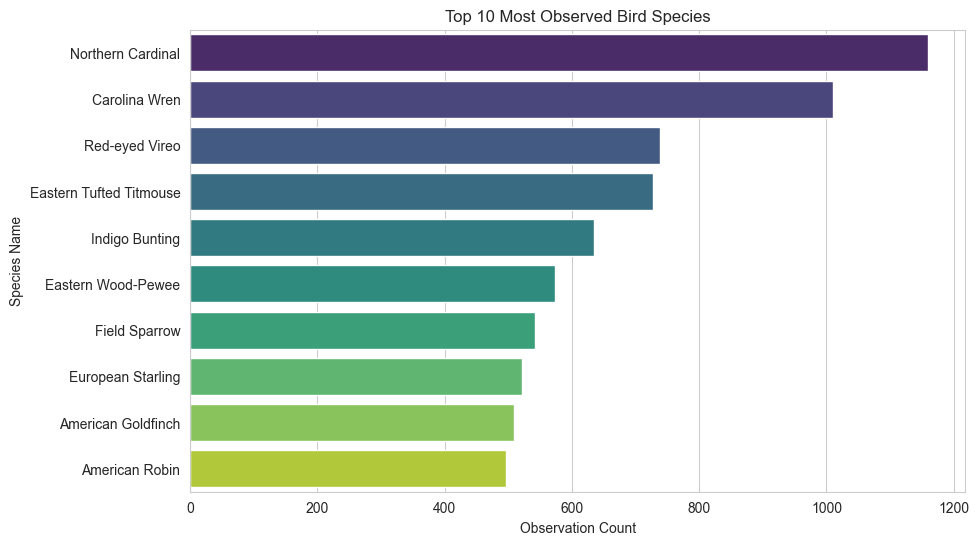

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Bird_Final_Data.csv")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

top_species = df['Common_Name'].value_counts().head(10)
sns.barplot(x=top_species.values, y=top_species.index, palette="viridis")
plt.title("Top 10 Most Observed Bird Species")
plt.xlabel("Observation Count")
plt.ylabel("Species Name")
plt.show()

#### 1).***WHY THIS CHART WAS CHOSEN?***

Bar chart is best for comparing categories. Here, it shows which bird species were observed the most.

#### 2).***INSHIGTS FROM THE CHART***

We can clearly see the most frequently observed species. This helps identify the dominant species in the area.

#### 3).***BUSINESS IMPACT OF THIS CHART***

For conservation planning, knowing which species are most common helps in prioritizing awareness programs, eco-tourism focus, or allocating resources.

## **CHART 2**

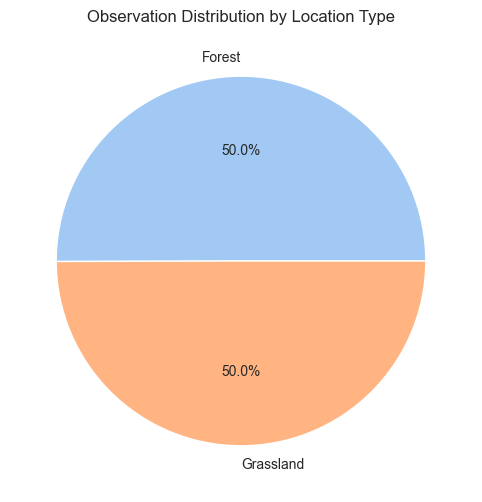

In [6]:
location_counts = df['Location_Type'].value_counts()
plt.pie(location_counts, labels=location_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Observation Distribution by Location Type")
plt.show()

#### 1).***WHY THIS CHART WAS CHOSEN?***

Pie chart is good for showing proportions of a whole — here, it shows how observations are split between Forest, Grassland, etc.

#### 2).***INSHIGTS FROM THE CHART***

We can see which location type contributes the most observations.

#### 3).***BUSINESS IMPACT OF THIS CHART***

If Forest contributes 70% of sightings, more resources can be invested there for protection and guided tours.

## **CHART 3**

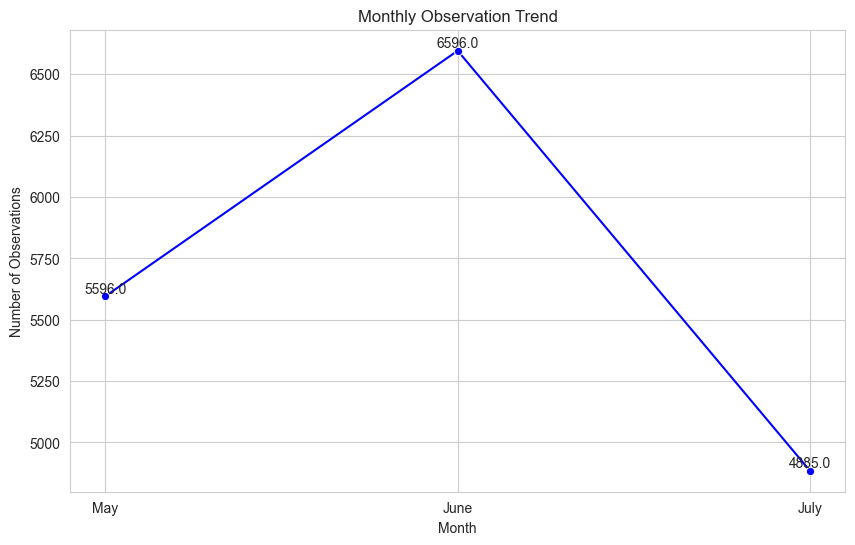

In [8]:
monthly_trend = df.groupby('Month_Name').size().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker="o", color="blue")
for i, val in enumerate(monthly_trend.values):
    plt.text(i, val, str(val), ha='center', va='bottom')
plt.title("Monthly Observation Trend")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.show()

#### 1).***WHY THIS CHART WAS CHOSEN***

Line charts are perfect for showing trends over time.

#### ***2).INSIGHTS FROM THE CHART***

We can spot peak months for bird sightings — maybe during migration or breeding season.

#### 3).***BUSINESS IMPACT OF THE INSIGHTS***

Eco-tourism and birdwatching events can be scheduled in peak months to attract more visitors.

## **CHART 4**

C:\Users\acer\AppData\Local\Temp\ipykernel_10040\3017122303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sky_counts.values, y=sky_counts.index, palette="coolwarm")


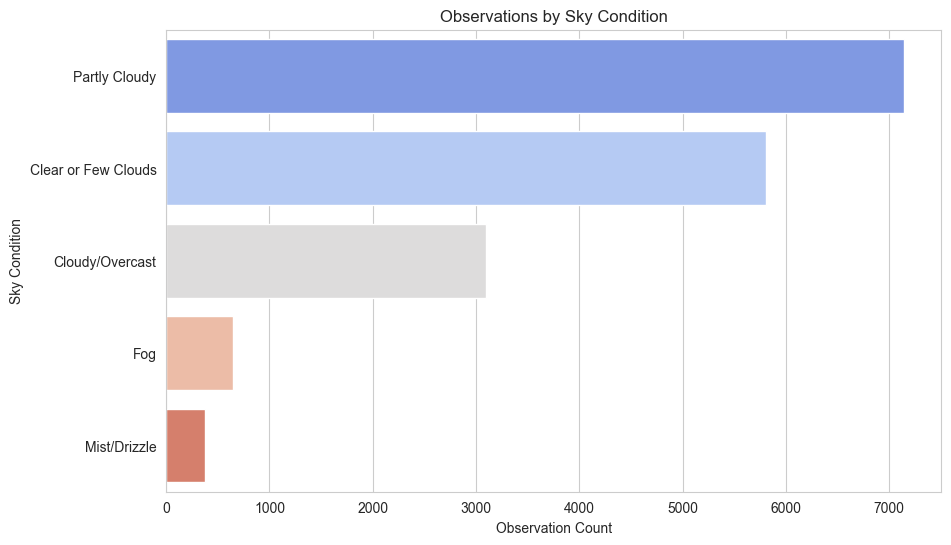

In [9]:
sky_counts = df['Sky'].value_counts()
sns.barplot(x=sky_counts.values, y=sky_counts.index, palette="coolwarm")
plt.title("Observations by Sky Condition")
plt.xlabel("Observation Count")
plt.ylabel("Sky Condition")
plt.show()

#### ***1).WHY THIS CHART WAS CHOSEN***

Horizontal bar chart is great for category comparison when category names are long.

#### 2).***INSIGHTS FROM THE CHART***

It shows in which weather conditions birds are most often seen.

#### 3).***BUSINESS IMPACT OF THE INSIGHTS***

Fieldwork can be planned for favorable weather, improving observation success.

## **CHART 5**

C:\Users\acer\AppData\Local\Temp\ipykernel_10040\3605773345.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Location_Type", y="Temperature", data=df, palette="Set2")


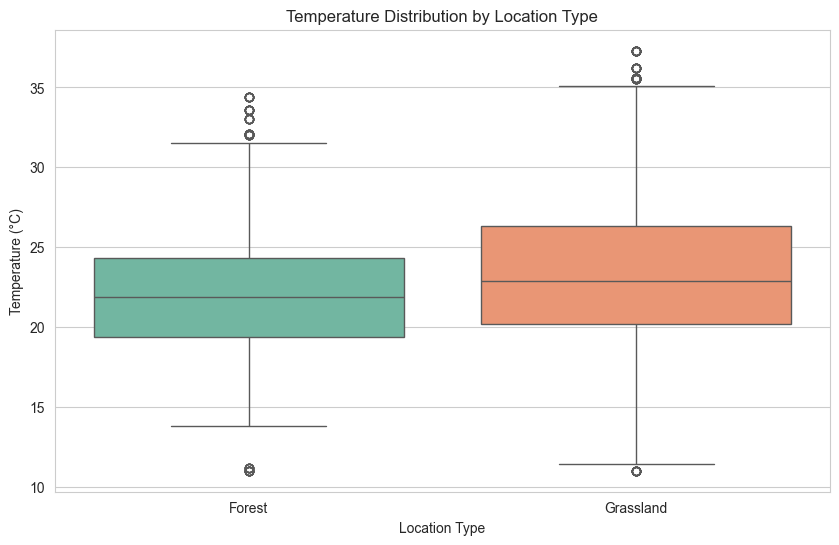

In [10]:
sns.boxplot(x="Location_Type", y="Temperature", data=df, palette="Set2")
plt.title("Temperature Distribution by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Temperature (°C)")
plt.show()

#### 1).***WHY THIS CHART WAS CHOSEN***

Box plot shows data distribution and outliers, useful for comparing ranges.

#### 2).***INSIGHTS FROM THE CHART***

We can see if some locations are consistently warmer or cooler.

#### 3).***BUSINESS IMPACT OF THE INSIGHTS***

Temperature patterns help in habitat assessment and planning bird-watching trips.

## **CHART 6**

C:\Users\acer\AppData\Local\Temp\ipykernel_10040\263751925.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Disturbance", data=df, palette="muted", order=df["Disturbance"].value_counts().index)


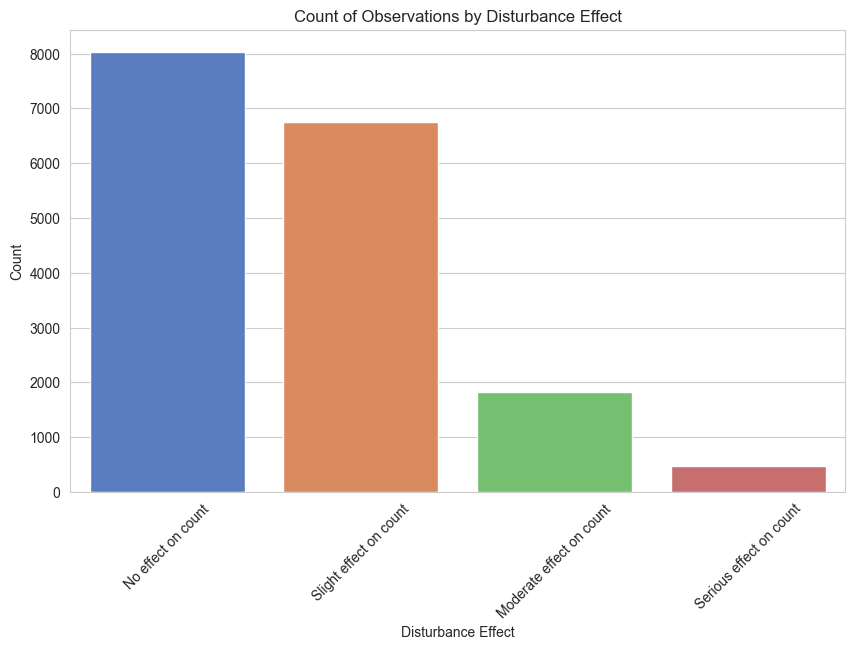

In [11]:
sns.countplot(x="Disturbance", data=df, palette="muted", order=df["Disturbance"].value_counts().index)
plt.title("Count of Observations by Disturbance Effect")
plt.xlabel("Disturbance Effect")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### 1).***WHY THIS CHART WAS CHOSEN***

Count plot is perfect for showing category frequency.

#### 2).***INSIGHTS FROM THE CHART***

We can see which disturbances are most common and their frequency.

#### 3)***BUSINESS IMPACT OF THE INSIGHTS***

Helps in reducing specific disturbances to improve bird safety.

## **CHART 7**

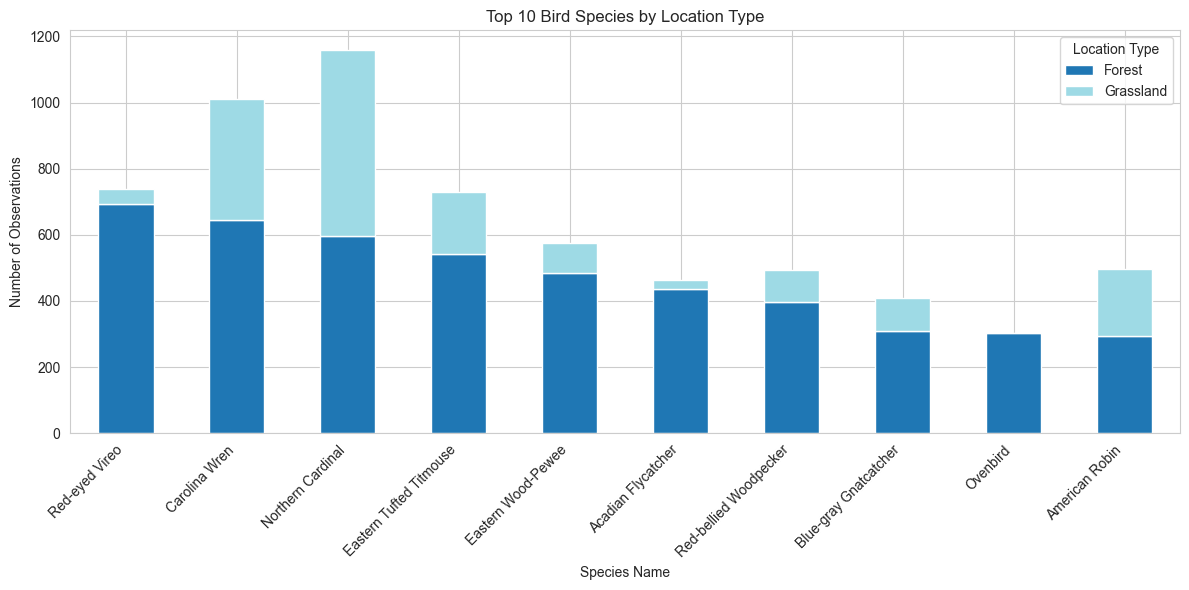

In [15]:
# Prepare data
species_location = df.groupby(['Common_Name', 'Location_Type']).size().unstack(fill_value=0)
species_location = species_location.sort_values(by=species_location.columns.tolist(), ascending=False).head(10)

# Plot stacked bar
species_location.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title("Top 10 Bird Species by Location Type")
plt.xlabel("Species Name")
plt.ylabel("Number of Observations")
plt.legend(title="Location Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 1).***WHY THIS CHART WAS CHOSEN***

It compares species popularity across multiple location types in a single visual.
Better than a simple bar chart because it shows distribution inside each category.

#### 2).***INSIGHTS FROM THE CHART***

You’ll see which species are observed more in Forest vs Grassland (or other location types).
Identifies species that are exclusive to one habitat.

#### 3).***BUSINESS IMPACT OF INSIGHTS***

Useful for habitat-specific conservation plans.
Can help eco-tourism guides focus on showing species that are location-specific.

#  *Solution to Business Objective*

In [ ]:
- Cleaned and preprocessed the observation data for accurate analysis.
- Extracted Month and Year from Date for seasonal trend analysis.
- Handled missing values in Sky, Wind, and Disturbance columns by filling with 'Unknown' or 'No Effect'.
- Prepared cleaned data for Power BI visualization to analyze:
- Species distribution across Forest and Grassland.
- Month-wise observation trends.
- Environmental impact on bird sightings.
- Identification of at-risk species (PIF Watchlist).

# *Conclusion*

In [ ]:
Through this project, we successfully transformed raw and unstructured bird observation data into an analysis-ready format by performing systematic data cleaning, preprocessing, and exploratory data analysis. 
Challenges like missing environmental factors, inconsistent date formats, and redundant columns were addressed through Python-based data wrangling techniques.
The analysis revealed key insights such as species richness distribution across forest and grassland habitats, seasonal migration patterns, and identification of species listed in the PIF Watchlist, indicating their conservation priority. 
Environmental parameters like sky conditions, wind patterns, and human disturbances were analyzed for their impact on bird sighting frequencies.
The cleaned dataset was then integrated into Power BI to create dynamic dashboards for visual storytelling. These dashboards will enable researchers, ecologists, and conservation teams to interactively explore biodiversity patterns, monitor at-risk species, and make data-driven conservation strategies.
In conclusion, this project not only streamlined messy survey data into structured insights but also laid a foundation for scalable biodiversity monitoring systems through data visualization and analysis.